# 🏝️ Tourism Experience Analytics
## Classification, Prediction, and Recommendation System

**Final Professional Notebook**

This notebook implements the complete workflow requested in the project brief:

- Data cleaning and validation
- Missing-value treatment and categorical standardization
- Consolidated tourism master dataset creation
- Exploratory Data Analysis (EDA) and business insights
- Rating prediction using regression with model comparison
- Visit-mode prediction using classification with model comparison
- Genuine user-personalized attraction recommendations using item-based collaborative filtering
- Recommendation-system evaluation using RMSE and Hit Rate@K
- Model/artifact export for Streamlit deployment

> **Important modeling note:** `VisitMode` is the classification target and is never used as an input feature. This avoids direct target leakage.

## 1. Project Objectives

The project brief defines three primary objectives: predict attraction ratings, predict a user's visit mode, and provide personalized attraction recommendations. It also requires EDA, model evaluation, business insights, and a Streamlit application. This notebook is organized to address those requirements in separate, reproducible sections.

In [ ]:
# 2. Imports and configuration
import os
import re
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42

# Resolve paths so the notebook works when opened from the project root
# or from the notebooks/ directory.
CANDIDATE_ROOTS = [Path("."), Path("..")]
ROOT = next((p for p in CANDIDATE_ROOTS if (p / "data").exists()), Path(".."))
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "outputs"
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Project root:", ROOT.resolve())
print("Data directory:", DATA_DIR.resolve())

Project root: /
Data directory: /data


## 3. Load the Source Datasets

The source package contains transaction, user, city, country, mode, continent, region, attraction type, and attraction-item tables. The transaction table is the central fact table and the remaining tables provide descriptive attributes.

In [ ]:
from pathlib import Path

# Redefine DATA_DIR to correctly point to the location of the .xlsx files
DATA_DIR = Path("/content/")

# 3. Load source datasets
transaction = pd.read_excel(DATA_DIR / "Transaction.xlsx")
mode = pd.read_excel(DATA_DIR / "Mode.xlsx")
city = pd.read_excel(DATA_DIR / "City.xlsx")
country = pd.read_excel(DATA_DIR / "Country.xlsx")
user = pd.read_excel(DATA_DIR / "User.xlsx")
type_df = pd.read_excel(DATA_DIR / "Type.xlsx")
continent = pd.read_excel(DATA_DIR / "Continent.xlsx")
region = pd.read_excel(DATA_DIR / "Region.xlsx")
item = pd.read_excel(DATA_DIR / "Updated_Item.xlsx")

datasets = {
    "Transaction": transaction,
    "Mode": mode,
    "City": city,
    "Country": country,
    "User": user,
    "Type": type_df,
    "Continent": continent,
    "Region": region,
    "Item": item,
}

summary = pd.DataFrame([
    {
        "Dataset": name,
        "Rows": len(frame),
        "Columns": frame.shape[1],
        "Duplicate rows": int(frame.duplicated().sum()),
        "Missing cells": int(frame.isna().sum().sum()),
    }
    for name, frame in datasets.items()
])

summary

,Dataset,Rows,Columns,Duplicate rows,Missing cells
0,Transaction,52930,7,0,0
1,Mode,6,2,0,0
2,City,9143,3,0,1
3,Country,165,3,0,0
4,User,33530,5,0,4
5,Type,17,2,0,0
6,Continent,6,2,0,0
7,Region,22,3,0,0
8,Item,1698,5,0,0


## 4. Data Quality Checks and Cleaning

The cleaning process:

1. Removes exact duplicate rows.
2. Validates primary-key uniqueness in lookup tables.
3. Checks foreign-key integrity before joining tables.
4. Restricts ratings to the expected 1–5 range.
5. Standardizes categorical fields.
6. Resolves the source inconsistency in `Updated_Item.AttractionTypeId`: most rows contain numeric type IDs, while a smaller set contains descriptive labels such as `Beach`, `Market`, `Museum`, `Park`, and `Temple`. These labels are standardized into explicit descriptive categories rather than being silently discarded.
7. Fills unresolved descriptive fields with `Unknown` after the joins.

In [ ]:
# 4.1 Remove exact duplicates
for name in datasets:
    datasets[name] = datasets[name].drop_duplicates().copy()

transaction = datasets["Transaction"]
mode = datasets["Mode"]
city = datasets["City"]
country = datasets["Country"]
user = datasets["User"]
type_df = datasets["Type"]
continent = datasets["Continent"]
region = datasets["Region"]
item = datasets["Item"]

# 4.2 Primary-key uniqueness checks
key_checks = {
    "Transaction.TransactionId": transaction["TransactionId"].is_unique,
    "User.UserId": user["UserId"].is_unique,
    "City.CityId": city["CityId"].is_unique,
    "Country.CountryId": country["CountryId"].is_unique,
    "Mode.VisitModeId": mode["VisitModeId"].is_unique,
    "Type.AttractionTypeId": type_df["AttractionTypeId"].is_unique,
    "Continent.ContinentId": continent["ContinentId"].is_unique,
    "Region.RegionId": region["RegionId"].is_unique,
    "Item.AttractionId": item["AttractionId"].is_unique,
}
print("Primary-key uniqueness:")
display(pd.Series(key_checks, name="Unique" ).to_frame())

# 4.3 Foreign-key integrity before joins
integrity = pd.DataFrame({
    "Check": [
        "Transaction -> User",
        "Transaction -> Attraction",
        "Transaction -> VisitMode",
        "Attraction -> City",
        "Attraction -> Type (numeric IDs only)",
    ],
    "Unmatched rows": [
        int((~transaction["UserId"].isin(user["UserId"])).sum()),
        int((~transaction["AttractionId"].isin(item["AttractionId"])).sum()),
        int((~transaction["VisitMode"].isin(mode["VisitModeId"])).sum()),
        int((~item["AttractionCityId"].isin(city["CityId"])).sum()),
        int(pd.to_numeric(item["AttractionTypeId"], errors="coerce").notna().sum() -
            pd.to_numeric(item["AttractionTypeId"], errors="coerce").isin(type_df["AttractionTypeId"]).sum())
    ]
})
display(integrity)

# 4.4 Rating validation
invalid_ratings = int((~transaction["Rating"].between(1, 5)).sum())
print("Invalid ratings outside 1–5:", invalid_ratings)
transaction = transaction[transaction["Rating"].between(1, 5)].copy()

Primary-key uniqueness:


,Unique
Transaction.TransactionId,True
User.UserId,True
City.CityId,True
Country.CountryId,True
Mode.VisitModeId,True
Type.AttractionTypeId,True
Continent.ContinentId,True
Region.RegionId,True
Item.AttractionId,True


,Check,Unmatched rows
0,Transaction -> User,0
1,Transaction -> Attraction,0
2,Transaction -> VisitMode,0
3,Attraction -> City,0
4,Attraction -> Type (numeric IDs only),0


Invalid ratings outside 1–5: 0


In [ ]:
# 4.5 Standardize attraction type values
# Numeric IDs are mapped from Type.xlsx. Textual legacy labels are standardized
# to descriptive categories and retained.
type_map = dict(zip(type_df["AttractionTypeId"], type_df["AttractionType"]))
legacy_type_map = {
    "Beach": "Beaches",
    "Market": "Flea & Street Markets",
    "Museum": "Museums",
    "Park": "National Parks",
    "Temple": "Religious Sites",
}

def resolve_attraction_type(value):
    if pd.isna(value):
        return "Unknown"
    numeric = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]
    if pd.notna(numeric) and numeric in type_map:
        return type_map[numeric]
    text = str(value).strip()
    if text in legacy_type_map:
        return legacy_type_map[text]
    return text if text else "Unknown"

item["AttractionTypeResolved"] = item["AttractionTypeId"].apply(resolve_attraction_type)

print("Resolved attraction-type values:")
display(item[["AttractionTypeId", "AttractionTypeResolved"]].drop_duplicates().sort_values("AttractionTypeResolved").head(30))

Resolved attraction-type values:


,AttractionTypeId,AttractionTypeResolved
25,2,Ancient Ruins
24,10,Ballets
0,13,Beaches
31,Beach,Beaches
20,19,Caverns & Caves
22,34,Flea & Street Markets
35,Market,Flea & Street Markets
29,44,Historic Sites
27,45,History Museums
33,Museum,Museums


## 5. Build the Consolidated Master Dataset

The tables are joined using validated many-to-one relationships. User geography and attraction geography are kept as separate fields so the model can distinguish where the user lives from where the attraction is located.

In [ ]:
# 5.1 Prepare renamed lookup tables
u = user.rename(columns={
    "ContinentId": "UserContinentId",
    "RegionId": "UserRegionId",
    "CountryId": "UserCountryId",
    "CityId": "UserCityId",
})

city_user = city.rename(columns={
    "CityId": "UserCityId",
    "CityName": "UserCityName",
    "CountryId": "UserCityCountryId",
})

city_attr = city.rename(columns={
    "CityId": "AttractionCityId",
    "CityName": "AttractionCityName",
    "CountryId": "AttractionCityCountryId",
})

country_user = country.rename(columns={
    "CountryId": "UserCountryId",
    "Country": "UserCountry",
    "RegionId": "UserCountryRegionId",
})

region_user = region.rename(columns={
    "RegionId": "UserRegionId",
    "Region": "UserRegion",
    "ContinentId": "UserRegionContinentId",
})

continent_user = continent.rename(columns={
    "ContinentId": "UserContinentId",
    "Continent": "UserContinent",
})

item_clean = item.drop(columns=["AttractionTypeId"]).merge(
    type_df.rename(columns={"AttractionTypeId": "AttractionTypeId_tmp"}),
    left_on="AttractionTypeResolved",
    right_on="AttractionType",
    how="left"
).drop(columns=["AttractionTypeId_tmp", "AttractionType"], errors="ignore")

# Keep the original item table's type identifier as a separate source field.
item_clean = item[["AttractionId", "AttractionCityId", "AttractionTypeId", "Attraction", "AttractionAddress", "AttractionTypeResolved"]].copy()

# 5.2 Sequential validated joins
master = transaction.merge(u, on="UserId", how="left", validate="many_to_one")
master = master.merge(mode, left_on="VisitMode", right_on="VisitModeId", how="left", validate="many_to_one", suffixes=("_id", "_label"))
master = master.merge(item_clean, on="AttractionId", how="left", validate="many_to_one")
master = master.merge(city_user, on="UserCityId", how="left", validate="many_to_one")
master = master.merge(city_attr, on="AttractionCityId", how="left", validate="many_to_one")
master = master.merge(country_user, on="UserCountryId", how="left", validate="many_to_one")
master = master.merge(region_user, on="UserRegionId", how="left", validate="many_to_one")
master = master.merge(continent_user, on="UserContinentId", how="left", validate="many_to_one")

# Clean final column names and categorical values.
master["VisitModeLabel"] = master["VisitMode_label"].fillna(master["VisitMode_id"].astype(str))
master["AttractionType"] = master["AttractionTypeResolved"].fillna("Unknown")

categorical_master_cols = [
    "VisitModeLabel", "Attraction", "AttractionAddress", "AttractionType",
    "UserCityName", "AttractionCityName", "UserCountry", "UserRegion", "UserContinent"
]
for col in categorical_master_cols:
    master[col] = master[col].astype("string").fillna("Unknown").astype(str)

numeric_master_cols = [
    "VisitYear", "VisitMonth", "Rating", "UserContinentId", "UserRegionId",
    "UserCountryId", "UserCityId", "AttractionId", "AttractionCityId"
]
for col in numeric_master_cols:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors="coerce")

print("Master shape:", master.shape)
print("Duplicate master rows:", master.duplicated().sum())
print("Missing cells after cleaning:", int(master.isna().sum().sum()))
display(master.head())

Master shape: (52930, 29)
Duplicate master rows: 0
Missing cells after cleaning: 16


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode_id,AttractionId,Rating,UserContinentId,UserRegionId,UserCountryId,UserCityId,VisitModeId,VisitMode_label,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionTypeResolved,UserCityName,UserCityCountryId,AttractionCityName,AttractionCityCountryId,UserCountry,UserCountryRegionId,UserRegion,UserRegionContinentId,UserContinent,VisitModeLabel,AttractionType
0,3,70456,2022,10,2,640,5,5,21,163,"4,341.000",2,Couples,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Guildford,109.000,Douala,1,United Kingdom,21,Western Europe,5,Europe,Couples,Nature & Wildlife Areas
1,8,7567,2022,10,4,640,5,2,8,48,464.000,4,Friends,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Ontario,48.000,Douala,1,Canada,8,Northern America,2,America,Friends,Nature & Wildlife Areas
2,9,79069,2022,10,3,640,5,2,9,54,774.000,3,Family,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Brazil,51.000,Douala,1,Brazil,9,South America,2,America,Family,Nature & Wildlife Areas
3,10,31019,2022,10,3,640,3,5,17,135,583.000,3,Family,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Zurich,48.000,Douala,1,Switzerland,17,Central Europe,5,Europe,Family,Nature & Wildlife Areas
4,15,43611,2022,10,2,640,3,5,21,163,"1,396.000",2,Couples,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Manchester,51.000,Douala,1,United Kingdom,21,Western Europe,5,Europe,Couples,Nature & Wildlife Areas


In [ ]:
# 5.3 Final missing-value report
missing_report = master.isna().sum().sort_values(ascending=False).to_frame("Missing values")
missing_report[missing_report["Missing values"] > 0].head(20)

### Missing-value treatment summary

The source data contains a small number of missing geographic values. These are preserved as `Unknown` rather than deleting otherwise valid transactions. This avoids unnecessary loss of observations while making the treatment explicit and reproducible.

## 6. Exploratory Data Analysis (EDA)

The following analysis covers the required demographic, visit-mode, attraction, rating, geographic, and temporal patterns.

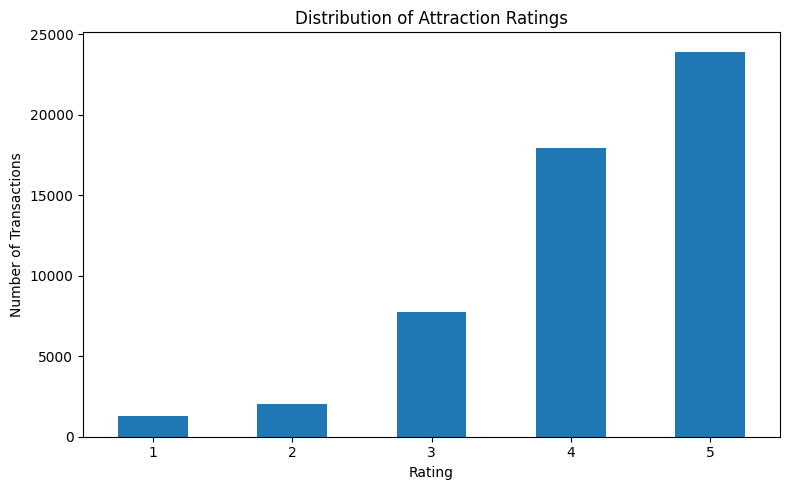

In [ ]:
# 6.1 Rating distribution
plt.figure(figsize=(8, 5))
master["Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Attraction Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 6.2 Visit mode distribution
plt.figure(figsize=(8, 5))
master["VisitModeLabel"].value_counts().plot(kind="bar")
plt.title("Transactions by Visit Mode")
plt.xlabel("Visit Mode")
plt.ylabel("Transactions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

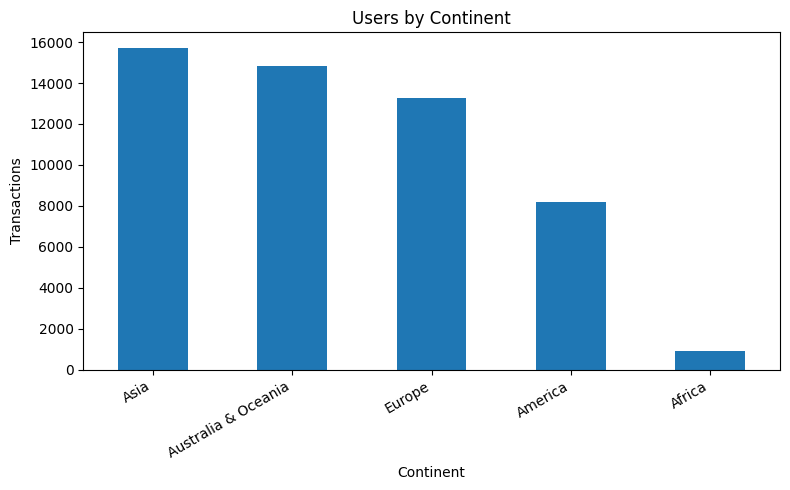

In [ ]:
# 6.3 User distribution by continent
plt.figure(figsize=(8, 5))
master["UserContinent"].value_counts().plot(kind="bar")
plt.title("Users by Continent")
plt.xlabel("Continent")
plt.ylabel("Transactions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

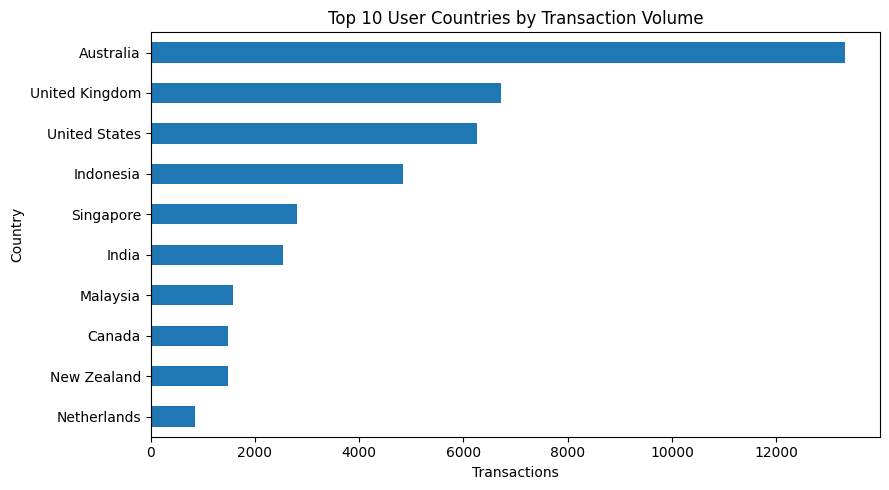

In [ ]:
# 6.4 User distribution by country
country_counts = master["UserCountry"].value_counts().head(10).sort_values()
plt.figure(figsize=(9, 5))
country_counts.plot(kind="barh")
plt.title("Top 10 User Countries by Transaction Volume")
plt.xlabel("Transactions")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

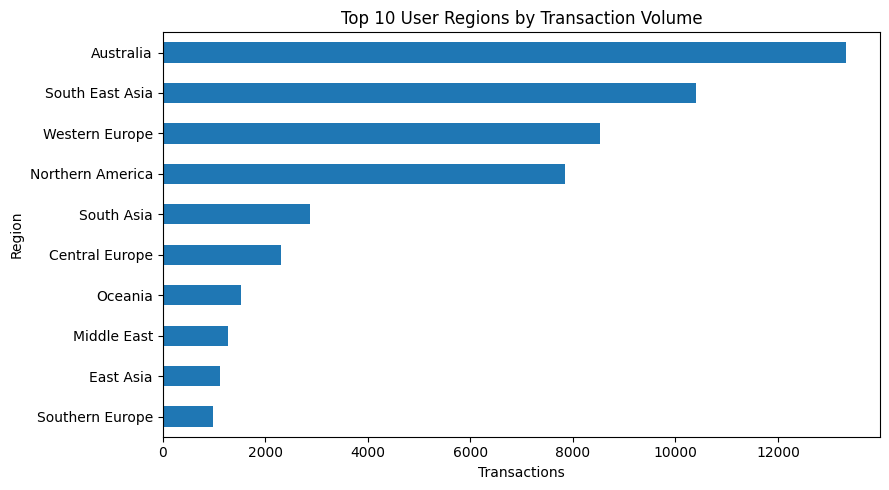

In [ ]:
# 6.5 User distribution by region
region_counts = master["UserRegion"].value_counts().head(10).sort_values()
plt.figure(figsize=(9, 5))
region_counts.plot(kind="barh")
plt.title("Top 10 User Regions by Transaction Volume")
plt.xlabel("Transactions")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

,Transactions,Average_Rating,Unique_Users
AttractionType,,,
Nature & Wildlife Areas,13251,4.267,11538
Beaches,10917,3.846,9411
Religious Sites,6711,4.207,5704
Water Parks,6429,4.647,5605
Points of Interest & Landmarks,6252,4.131,5712
Volcanos,2318,4.101,935
Waterfalls,2245,3.897,2204
Flea & Street Markets,1324,3.869,521
History Museums,978,4.257,477


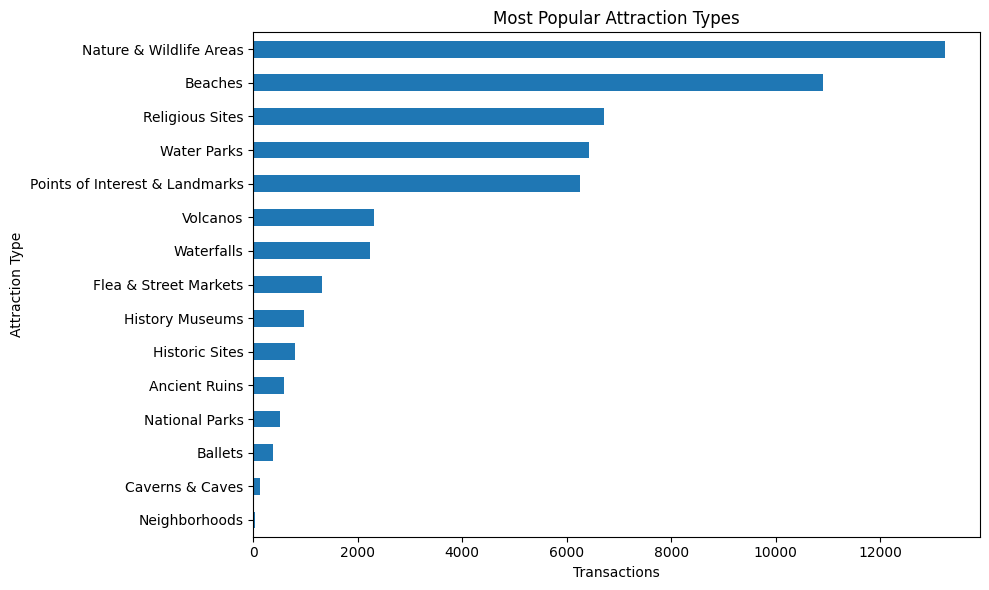

In [ ]:
# 6.6 Attraction types and popularity
attraction_type_summary = master.groupby("AttractionType").agg(
    Transactions=("TransactionId", "count"),
    Average_Rating=("Rating", "mean"),
    Unique_Users=("UserId", "nunique")
).sort_values("Transactions", ascending=False)

display(attraction_type_summary.head(15))

plt.figure(figsize=(10, 6))
attraction_type_summary.head(15)["Transactions"].sort_values().plot(kind="barh")
plt.title("Most Popular Attraction Types")
plt.xlabel("Transactions")
plt.ylabel("Attraction Type")
plt.tight_layout()
plt.show()

,count,mean
AttractionType,,
Water Parks,6429,4.647
Spas,28,4.571
Caverns & Caves,135,4.504
National Parks,511,4.417
Neighborhoods,44,4.318
Nature & Wildlife Areas,13251,4.267
History Museums,978,4.257
Religious Sites,6711,4.207
Ballets,377,4.180


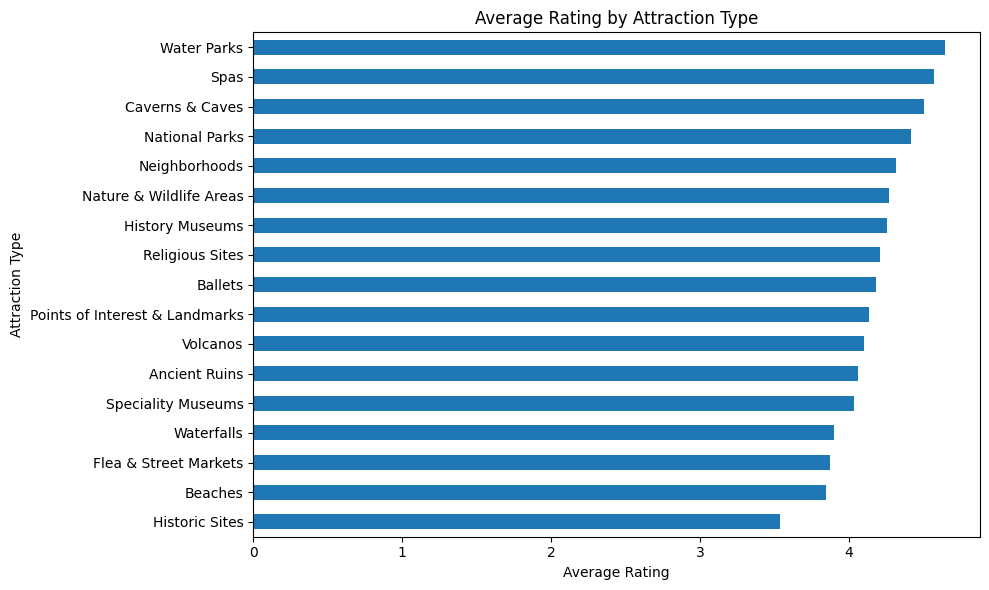

In [ ]:
# 6.7 Average rating by attraction type
rating_by_type = master.groupby("AttractionType")["Rating"].agg(["count", "mean"]).sort_values("mean", ascending=False)
display(rating_by_type.head(15))

plt.figure(figsize=(10, 6))
rating_by_type["mean"].sort_values().plot(kind="barh")
plt.title("Average Rating by Attraction Type")
plt.xlabel("Average Rating")
plt.ylabel("Attraction Type")
plt.tight_layout()
plt.show()

,Transactions,Average_Rating,Unique_Users
VisitYear,,,
2013,2983,4.167,2557
2014,4808,4.178,3735
2015,8687,4.210,6341
2016,12823,4.172,8714
2017,9444,4.077,6342
2018,7461,4.066,5144
2019,5913,4.252,4212
2020,529,4.297,430
2021,35,4.543,28


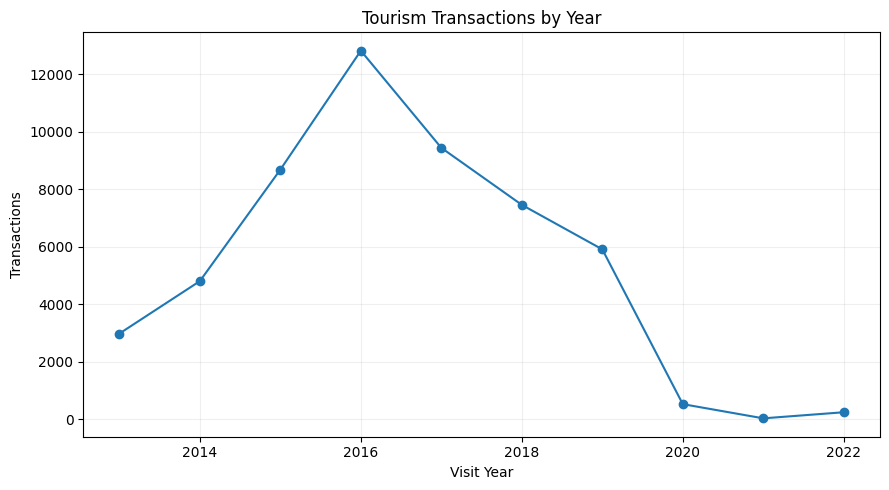

In [ ]:
# 6.8 Tourism trend by year
yearly = master.groupby("VisitYear").agg(
    Transactions=("TransactionId", "count"),
    Average_Rating=("Rating", "mean"),
    Unique_Users=("UserId", "nunique")
).sort_index()
display(yearly)

plt.figure(figsize=(9, 5))
yearly["Transactions"].plot(marker="o")
plt.title("Tourism Transactions by Year")
plt.xlabel("Visit Year")
plt.ylabel("Transactions")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

VisitModeLabel,Business,Couples,Family,Friends,Solo
UserContinent,,,,,
Africa,4,451,202,197,66
America,101,3560,1560,1915,1051
Asia,369,5228,4890,3715,1491
Australia & Oceania,55,5554,5833,2604,806
Europe,94,6827,2732,2514,1111


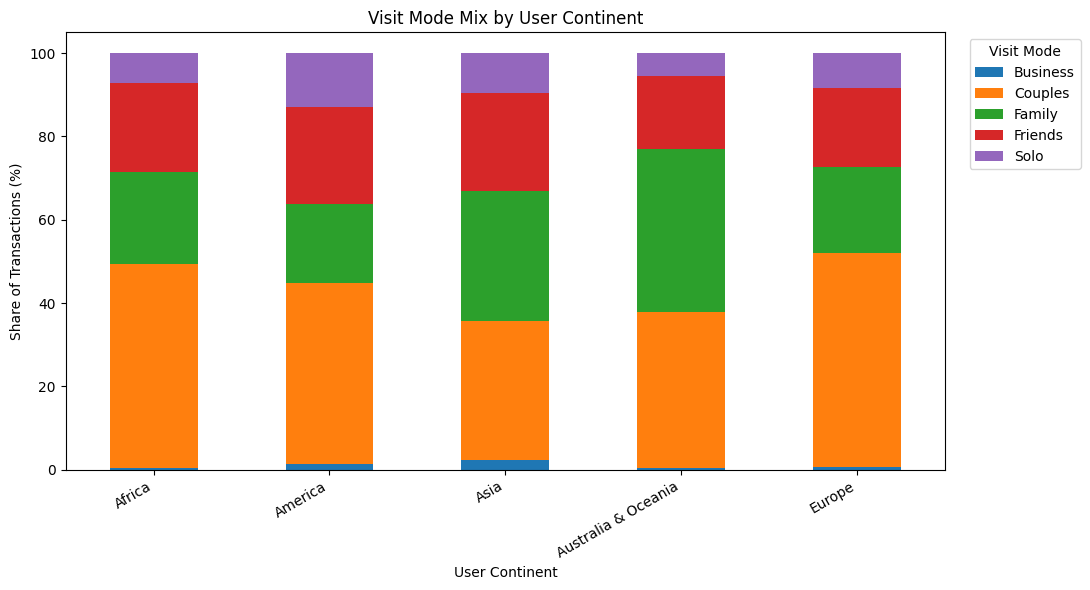

In [ ]:
# 6.9 Visit mode vs user continent
mode_continent = pd.crosstab(master["UserContinent"], master["VisitModeLabel"])
display(mode_continent)

mode_continent_pct = mode_continent.div(mode_continent.sum(axis=1), axis=0) * 100
plt.figure(figsize=(11, 6))
mode_continent_pct.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Visit Mode Mix by User Continent")
plt.xlabel("User Continent")
plt.ylabel("Share of Transactions (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Visit Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# 6.10 Top attractions by volume and quality
attraction_summary = master.groupby(["AttractionId", "Attraction"]).agg(
    Transactions=("TransactionId", "count"),
    Average_Rating=("Rating", "mean"),
    Unique_Users=("UserId", "nunique")
).reset_index()

display(attraction_summary.sort_values("Transactions", ascending=False).head(10))

# Use a minimum review threshold for a more meaningful quality ranking.
quality_ranking = attraction_summary[attraction_summary["Transactions"] >= 20].sort_values(
    ["Average_Rating", "Transactions"], ascending=[False, False]
).head(10)
display(quality_ranking)

,AttractionId,Attraction,Transactions,Average_Rating,Unique_Users
2,640,Sacred Monkey Forest Sanctuary,13198,4.267,11487
9,841,Waterbom Bali,6429,4.647,5605
6,748,Tegalalang Rice Terrace,5815,4.158,5415
8,824,Uluwatu Temple,3359,4.219,3183
5,737,Tanah Lot Temple,3352,4.195,3156
3,650,Sanur Beach,3044,3.976,2808
4,673,Seminyak Beach,2914,3.801,2754
0,369,Kuta Beach - Bali,2765,3.415,2571
23,1171,Merapi Volcano,2235,4.079,855
7,749,Tegenungan Waterfall,2190,3.895,2152


,AttractionId,Attraction,Transactions,Average_Rating,Unique_Users
17,947,Mount Semeru Volcano,83,4.699,83
9,841,Waterbom Bali,6429,4.647,5605
11,888,Bromo Tengger Semeru National Park,381,4.612,381
15,928,Khayangan Reflexology & Massage,28,4.571,28
20,1133,Jomblang Cave,135,4.504,119
14,920,Jodipan Colorful Village,44,4.318,43
1,481,Nusa Dua Beach,2104,4.276,1992
2,640,Sacred Monkey Forest Sanctuary,13198,4.267,11487
27,1278,Ullen Sentalu Museum,978,4.257,477
8,824,Uluwatu Temple,3359,4.219,3183


## 7. Business Insights from EDA

The tables and charts above should be interpreted in terms of tourism-platform decisions. The following code produces a compact set of stakeholder-oriented findings directly from the data rather than using invented statements.

In [ ]:
# 7.1 Automatically generated business insight values
most_common_mode = master["VisitModeLabel"].value_counts().idxmax()
most_common_mode_pct = master["VisitModeLabel"].value_counts(normalize=True).max() * 100
largest_continent = master["UserContinent"].value_counts().idxmax()
most_popular_type = attraction_type_summary.index[0]
highest_rated_type = rating_by_type.index[0]
busiest_year = yearly["Transactions"].idxmax()

print(f"• The most common visit mode is {most_common_mode}, representing {most_common_mode_pct:.1f}% of transactions.")
print(f"• The continent with the highest transaction volume is {largest_continent}.")
print(f"• The most frequently visited attraction type is {most_popular_type}.")
print(f"• The highest-average-rated attraction type in the observed data is {highest_rated_type}.")
print(f"• The busiest recorded visit year is {busiest_year}.")

• The most common visit mode is Couples, representing 40.8% of transactions.
• The continent with the highest transaction volume is Asia.
• The most frequently visited attraction type is Nature & Wildlife Areas.
• The highest-average-rated attraction type in the observed data is Water Parks.
• The busiest recorded visit year is 2016.


## 8. Feature Preparation for Machine Learning

For both predictive tasks, categorical variables are one-hot encoded. Numerical variables are retained as numeric values. `VisitMode` is excluded from the feature matrix for classification because it is the target.

The selected features are based on the information available in the consolidated dataset and the project brief: user geography, visit timing, and attraction characteristics.

In [ ]:
# 8.1 Shared predictive features
feature_cols = [
    "VisitYear",
    "VisitMonth",
    "UserContinent",
    "UserRegion",
    "UserCountry",
    "AttractionType",
    "AttractionCityName",
]

numeric_features = ["VisitYear", "VisitMonth"]
categorical_features = [
    "UserContinent", "UserRegion", "UserCountry",
    "AttractionType", "AttractionCityName"
]

model_df = master[feature_cols + ["Rating", "VisitModeLabel"]].copy()
for col in categorical_features:
    model_df[col] = model_df[col].fillna("Unknown").astype(str)
for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    model_df[col] = model_df[col].fillna(model_df[col].median())

X = model_df[feature_cols]
print("Feature matrix shape:", X.shape)

Feature matrix shape: (52930, 7)


# 9. Regression — Predict Attraction Ratings

### Target
`Rating` on the observed 1–5 scale.

### Model comparison
Two models are compared:

- **Ridge Regression** — a regularized linear baseline.
- **Random Forest Regressor** — a nonlinear ensemble model suited to mixed feature patterns.

The final deployment model is selected using RMSE, with R² and MAE reported for interpretation.

In [ ]:
# 9.1 Train/test split for regression
X_reg = model_df[feature_cols]
y_reg = model_df["Rating"].astype(float)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

reg_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

reg_models = {
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=60,
        max_depth=14,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

reg_results = []
reg_fitted = {}

for name, estimator in reg_models.items():
    pipe = Pipeline([
        ("preprocessor", reg_preprocessor),
        ("model", estimator),
    ])
    pipe.fit(X_train_r, y_train_r)
    pred = pipe.predict(X_test_r)
    metrics = {
        "Model": name,
        "MAE": mean_absolute_error(y_test_r, pred),
        "RMSE": mean_squared_error(y_test_r, pred) ** 0.5,
        "R2": r2_score(y_test_r, pred),
    }
    reg_results.append(metrics)
    reg_fitted[name] = (pipe, pred)

reg_comparison = pd.DataFrame(reg_results).sort_values("RMSE")
display(reg_comparison)

,Model,MAE,RMSE,R2
1,Random Forest,0.716,0.920,0.101
0,Ridge Regression,0.726,0.931,0.081


Selected regression model: Random Forest
Best regression metrics:


,Model,MAE,RMSE,R2
1,Random Forest,0.716,0.920,0.101


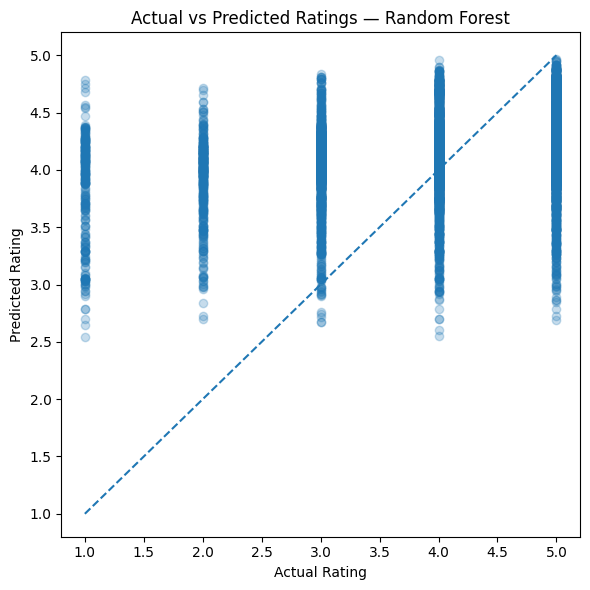

In [ ]:
# 9.2 Select and save the best regression model
best_reg_name = reg_comparison.iloc[0]["Model"]
reg_model = reg_fitted[best_reg_name][0]
reg_pred = reg_fitted[best_reg_name][1]

print("Selected regression model:", best_reg_name)
print("Best regression metrics:")
display(reg_comparison.iloc[[0]])

plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, reg_pred, alpha=0.25)
plt.plot([1, 5], [1, 5], linestyle="--")
plt.title(f"Actual vs Predicted Ratings — {best_reg_name}")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.tight_layout()
plt.show()

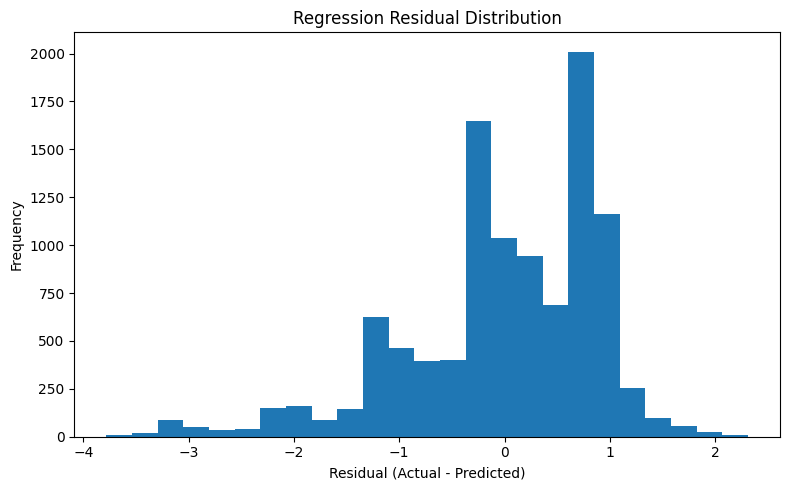

In [ ]:
# 9.3 Regression residual diagnostics
residuals = y_test_r.to_numpy() - reg_pred
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25)
plt.title("Regression Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 10. Classification — Predict User Visit Mode

### Target
`VisitModeLabel`.

The target is not included among the predictors. This prevents direct leakage from the answer into the model.

### Model comparison
- **Logistic Regression** provides a strong, interpretable linear baseline.
- **Random Forest Classifier** captures nonlinear relationships and interactions.

Accuracy, weighted precision, weighted recall, and weighted F1 are reported. A confusion matrix is also included.

In [ ]:
# 10.1 Train/test split for classification
X_clf = model_df[feature_cols]
y_clf = model_df["VisitModeLabel"].astype(str)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf
)

clf_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

clf_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=1.0, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=60,
        max_depth=16,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
    ),
}

clf_results = []
clf_fitted = {}

for name, estimator in clf_models.items():
    pipe = Pipeline([
        ("preprocessor", clf_preprocessor),
        ("model", estimator),
    ])
    pipe.fit(X_train_c, y_train_c)
    pred = pipe.predict(X_test_c)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test_c, pred),
        "Precision_weighted": precision_score(y_test_c, pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_test_c, pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_test_c, pred, average="weighted", zero_division=0),
    }
    clf_results.append(metrics)
    clf_fitted[name] = (pipe, pred)

clf_comparison = pd.DataFrame(clf_results).sort_values("F1_weighted", ascending=False)
display(clf_comparison)

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
1,Random Forest,0.380,0.443,0.380,0.401
0,Logistic Regression,0.326,0.412,0.326,0.353


Selected classification model: Random Forest


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
1,Random Forest,0.380,0.443,0.380,0.401


Classification report:
              precision    recall  f1-score   support

    Business       0.05      0.57      0.09       125
     Couples       0.54      0.48      0.51      4324
      Family       0.49      0.40      0.44      3043
     Friends       0.34      0.18      0.23      2189
        Solo       0.16      0.29      0.20       905

    accuracy                           0.38     10586
   macro avg       0.31      0.38      0.30     10586
weighted avg       0.44      0.38      0.40     10586



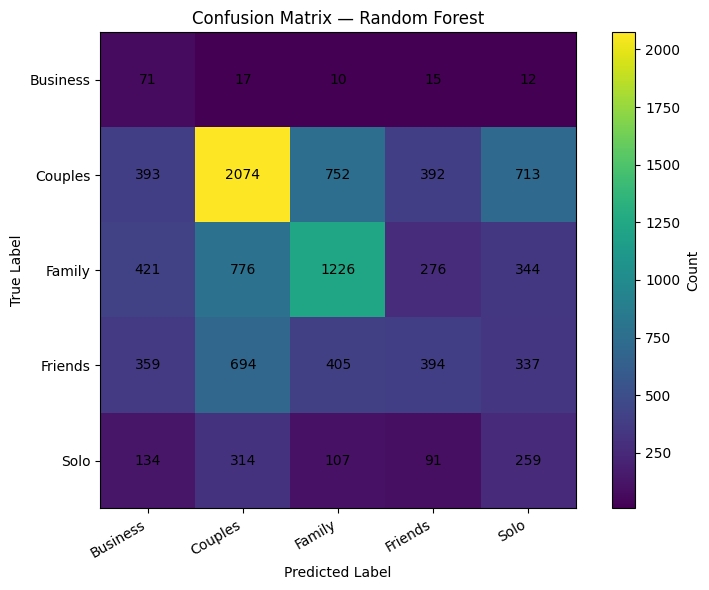

In [ ]:
# 10.2 Select and inspect the best classifier
best_clf_name = clf_comparison.iloc[0]["Model"]
clf_model = clf_fitted[best_clf_name][0]
clf_pred = clf_fitted[best_clf_name][1]

print("Selected classification model:", best_clf_name)
display(clf_comparison.iloc[[0]])

print("Classification report:")
print(classification_report(y_test_c, clf_pred, zero_division=0))

labels = sorted(y_clf.unique())
cm = confusion_matrix(y_test_c, clf_pred, labels=labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix — {best_clf_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
plt.yticks(range(len(labels)), labels)
plt.colorbar(label="Count")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

## 11. Model Comparison Summary

The project brief explicitly asks for comparison of different models. The following table combines the selected regression and classification comparisons so the final report can reference the evidence directly.

In [ ]:
print("Regression model comparison")
display(reg_comparison)
print("Classification model comparison")
display(clf_comparison)

Regression model comparison


,Model,MAE,RMSE,R2
1,Random Forest,0.716,0.920,0.101
0,Ridge Regression,0.726,0.931,0.081


Classification model comparison


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
1,Random Forest,0.380,0.443,0.380,0.401
0,Logistic Regression,0.326,0.412,0.326,0.353


## 12. Genuine User-Personalized Recommendation System

The recommendation requirement calls for suggestions based on historical user preferences and similar users' preferences. Because the transaction data contains `UserId`, `AttractionId`, and `Rating`, a user-item interaction matrix can be built.

### Approach: Item-based Collaborative Filtering

1. Build a user × attraction rating matrix.
2. Hold out one interaction per eligible user for evaluation.
3. Compute attraction-to-attraction cosine similarity using the training interactions.
4. For a selected user, use the attractions they have already rated as the user's preference profile.
5. Weight similar unseen attractions by the user's historical ratings.
6. Exclude attractions already visited by the user.
7. Return the highest-scoring unseen attractions.

This is genuinely personalized because two users with different historical ratings can receive different recommendations.

In [ ]:
# 12.1 Build an evaluation split for recommendation
interaction_cols = ["UserId", "AttractionId", "Rating"]
interactions = master[interaction_cols].dropna().copy()
interactions["UserId"] = interactions["UserId"].astype(int)
interactions["AttractionId"] = interactions["AttractionId"].astype(int)
interactions["Rating"] = interactions["Rating"].astype(float)

# If a user rated the same attraction multiple times, use the mean rating.
interactions = interactions.groupby(["UserId", "AttractionId"], as_index=False)["Rating"].mean()

rng = np.random.default_rng(RANDOM_STATE)
eligible_users = interactions.groupby("UserId").size()
eligible_users = eligible_users[eligible_users >= 2].index

# One held-out attraction per eligible user.
holdout_idx = []
for uid in eligible_users:
    user_rows = interactions.index[interactions["UserId"].eq(uid)].to_numpy()
    holdout_idx.append(rng.choice(user_rows))

holdout_idx = np.array(holdout_idx, dtype=int)
holdout = interactions.loc[holdout_idx].copy()
train_interactions = interactions.drop(index=holdout_idx).copy()

print("Unique users:", interactions["UserId"].nunique())
print("Users eligible for recommendation evaluation:", len(eligible_users))
print("Train interactions:", len(train_interactions))
print("Held-out interactions:", len(holdout))

Unique users: 33530
Users eligible for recommendation evaluation: 7934
Train interactions: 37341
Held-out interactions: 7934


In [ ]:
# 12.2 Create training user-item matrix and item-item similarity
user_ids = np.sort(train_interactions["UserId"].unique())
item_ids = np.sort(train_interactions["AttractionId"].unique())

user_index = {uid: i for i, uid in enumerate(user_ids)}
item_index = {iid: i for i, iid in enumerate(item_ids)}

rows = train_interactions["UserId"].map(user_index).to_numpy()
cols = train_interactions["AttractionId"].map(item_index).to_numpy()
vals = train_interactions["Rating"].to_numpy(dtype=float)

train_matrix = csr_matrix(
    (vals, (rows, cols)),
    shape=(len(user_ids), len(item_ids))
)

# Sparse cosine similarity keeps memory use practical for this dataset.
item_similarity = cosine_similarity(train_matrix.T, dense_output=True)

print("User-item matrix shape:", train_matrix.shape)
print("Item-item similarity shape:", item_similarity.shape)

User-item matrix shape: (33530, 30)
Item-item similarity shape: (30, 30)


In [ ]:
# 12.3 Item-based personalized recommender
item_meta = master[["AttractionId", "Attraction", "AttractionCityName", "AttractionType", "AttractionAddress"]].drop_duplicates("AttractionId").copy()
item_meta["AttractionId"] = item_meta["AttractionId"].astype(int)
item_meta = item_meta.set_index("AttractionId")

train_global_mean = train_interactions["Rating"].mean()


def recommend_for_user(user_id, top_n=5, neighborhood_size=50):
    """Return personalized recommendations for a user based on their training history."""
    if user_id not in user_index:
        # Cold-start fallback: popular, highly rated attractions.
        popular = train_interactions.groupby("AttractionId").agg(
            Average_Rating=("Rating", "mean"),
            Rating_Count=("Rating", "count")
        ).reset_index()
        popular["Score"] = popular["Average_Rating"] + 0.05 * np.log1p(popular["Rating_Count"])
        rec = popular.sort_values("Score", ascending=False).head(top_n)
        return rec.merge(item_meta.reset_index(), on="AttractionId", how="left")

    uidx = user_index[user_id]
    user_row = train_matrix.getrow(uidx)
    rated_positions = user_row.indices
    rated_scores = user_row.data

    candidate_scores = np.zeros(len(item_ids), dtype=float)
    candidate_weights = np.zeros(len(item_ids), dtype=float)

    for pos, rating in zip(rated_positions, rated_scores):
        sim = item_similarity[pos].copy()
        sim[pos] = 0.0
        top_neighbors = np.argsort(sim)[::-1][:neighborhood_size]
        positive = sim[top_neighbors] > 0
        top_neighbors = top_neighbors[positive]
        sim_values = sim[top_neighbors]
        candidate_scores[top_neighbors] += sim_values * rating
        candidate_weights[top_neighbors] += sim_values

    predicted = np.divide(
        candidate_scores,
        candidate_weights,
        out=np.full_like(candidate_scores, train_global_mean),
        where=candidate_weights > 0
    )

    # Exclude attractions the user has already rated.
    predicted[rated_positions] = -np.inf
    order = np.argsort(predicted)[::-1][:top_n]
    rec = pd.DataFrame({
        "AttractionId": item_ids[order],
        "RecommendationScore": predicted[order]
    })
    return rec.merge(item_meta.reset_index(), on="AttractionId", how="left")

# Example using an eligible user
example_user = int(next(iter(eligible_users)))
display(recommend_for_user(example_user, top_n=5))

,AttractionId,RecommendationScore,Attraction,AttractionCityName,AttractionType,AttractionAddress
0,1297,5.000,Yogyakarta Palace,N'Djamena,Historic Sites,Yogyakarta
1,1280,5.000,Water Castle (Tamansari),N'Djamena,Points of Interest & Landmarks,"Jl. Taman, 55133 Indonesia"
2,1278,5.000,Ullen Sentalu Museum,N'Djamena,History Museums,"Jl. Boyong Taman Wisata, 55581 Indonesia"
3,1238,5.000,Sewu Temple,N'Djamena,Ancient Ruins,Yogyakarta
4,1220,5.000,Ramayana Ballet at Prambanan,N'Djamena,Ballets,Sleman


## 13. Recommendation-System Evaluation

A recommendation system needs an evaluation step rather than only producing a list.

Two metrics are used:

- **RMSE:** compares the predicted preference score for a held-out attraction against the user's actual rating.
- **Hit Rate@5:** checks whether the held-out attraction appears among the top five recommendations for the user.

Only users with at least two unique rated attractions are used for this holdout evaluation, because a historical interaction is needed to learn a user preference profile.

In [ ]:
# 13.1 Evaluate held-out ratings and top-5 hits
actual_ratings = []
predicted_ratings = []
hits = 0
eligible_eval = 0

evaluation_holdout = holdout.sample(n=min(1000, len(holdout)), random_state=RANDOM_STATE)
print(f"Evaluation sample size: {len(evaluation_holdout):,}")

for row in evaluation_holdout.itertuples(index=False):
    uid = int(row.UserId)
    target_item = int(row.AttractionId)
    actual = float(row.Rating)

    if uid not in user_index or target_item not in item_index:
        continue

    recs = recommend_for_user(uid, top_n=5)
    if recs.empty:
        continue

    # The recommender's score is a predicted preference score.
    target_match = recs.loc[recs["AttractionId"].eq(target_item), "RecommendationScore"]
    if len(target_match):
        predicted = float(target_match.iloc[0])
    else:
        # For RMSE, compute the same scoring logic at the target item.
        uidx = user_index[uid]
        user_row = train_matrix.getrow(uidx)
        target_pos = item_index[target_item]
        rated_positions = user_row.indices
        rated_scores = user_row.data
        sims = item_similarity[target_pos, rated_positions]
        denom = np.abs(sims).sum()
        predicted = float(np.dot(sims, rated_scores) / denom) if denom > 0 else train_global_mean

    predicted = float(np.clip(predicted, 1, 5))
    actual_ratings.append(actual)
    predicted_ratings.append(predicted)
    eligible_eval += 1

    if target_item in set(recs["AttractionId"].tolist()):
        hits += 1

recommendation_rmse = mean_squared_error(actual_ratings, predicted_ratings) ** 0.5 if actual_ratings else np.nan
hit_rate_at_5 = hits / eligible_eval if eligible_eval else np.nan

recommendation_metrics = pd.DataFrame([{
    "Metric": "RMSE",
    "Value": recommendation_rmse,
}, {
    "Metric": "Hit Rate@5",
    "Value": hit_rate_at_5,
}])

display(recommendation_metrics)
print(f"Evaluated users/interactions: {eligible_eval:,}")
print("Note: a fixed random sample of up to 1,000 eligible holdouts is used to keep notebook execution practical while preserving reproducibility.")

Evaluation sample size: 1,000


,Metric,Value
0,RMSE,1.146
1,Hit Rate@5,0.030


Evaluated users/interactions: 1,000
Note: a fixed random sample of up to 1,000 eligible holdouts is used to keep notebook execution practical while preserving reproducibility.


## 14. Recommendation Example for Different Users

A useful demonstration of personalization is to compare recommendations for two different users with different histories. The output below uses only historical interactions available in the training data.

In [ ]:
# 14.1 Show recommendation examples for two eligible users
example_users = list(eligible_users[:2])
for uid in example_users:
    print(f"Recommendations for User {int(uid)}")
    display(recommend_for_user(int(uid), top_n=5)[
        ["Attraction", "AttractionCityName", "AttractionType", "RecommendationScore"]
    ])

Recommendations for User 14


,Attraction,AttractionCityName,AttractionType,RecommendationScore
0,Yogyakarta Palace,N'Djamena,Historic Sites,5.000
1,Water Castle (Tamansari),N'Djamena,Points of Interest & Landmarks,5.000
2,Ullen Sentalu Museum,N'Djamena,History Museums,5.000
3,Sewu Temple,N'Djamena,Ancient Ruins,5.000
4,Ramayana Ballet at Prambanan,N'Djamena,Ballets,5.000


Recommendations for User 16


,Attraction,AttractionCityName,AttractionType,RecommendationScore
0,Ramayana Ballet at Prambanan,N'Djamena,Ballets,5.000
1,Goa Cina Beach,South Region,Beaches,5.000
2,Balekambang Beach,South Region,Beaches,5.000
3,Ullen Sentalu Museum,N'Djamena,History Museums,4.860
4,Bromo Tengger Semeru National Park,South Region,National Parks,4.840


## 15. Feature Importance — Final Random Forest Models

Feature importance is reported for the Random Forest models when they are selected as the best model. This provides an additional interpretation layer for stakeholders.

,Importance
cat__AttractionType_Water Parks,0.197
num__VisitMonth,0.180
num__VisitYear,0.154
cat__AttractionType_Beaches,0.094
cat__AttractionType_Historic Sites,0.039
cat__UserCountry_Indonesia,0.024
cat__AttractionType_Waterfalls,0.016
cat__AttractionType_Nature & Wildlife Areas,0.013
cat__UserCountry_Singapore,0.011
cat__UserContinent_Europe,0.011


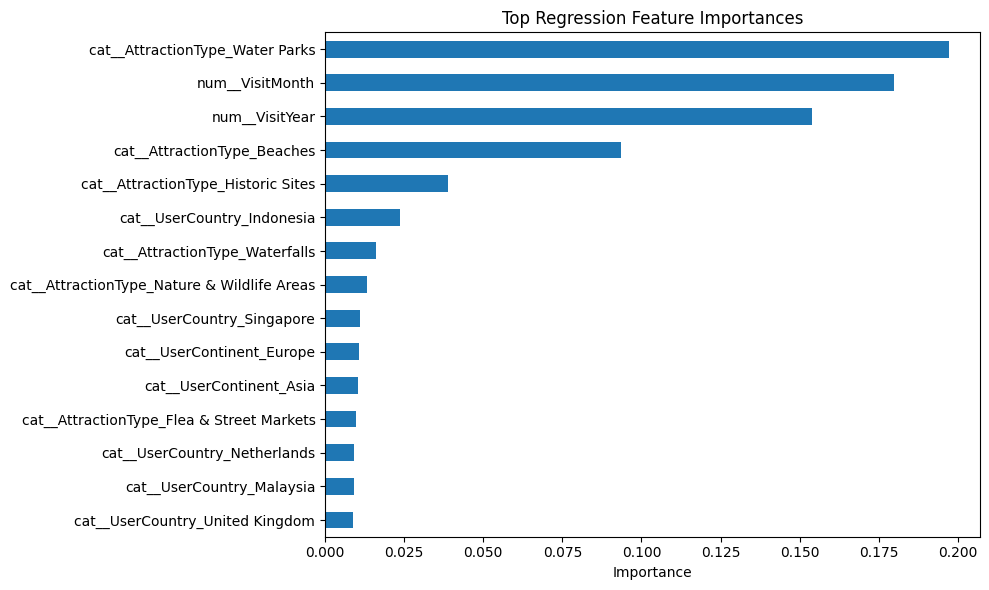

,Importance
num__VisitMonth,0.244
num__VisitYear,0.182
cat__AttractionType_Water Parks,0.069
cat__UserCountry_Indonesia,0.046
cat__UserRegion_South East Asia,0.043
cat__AttractionCityName_N'Djamena,0.033
cat__AttractionCityName_Douala,0.031
cat__UserContinent_Australia & Oceania,0.023
cat__AttractionType_Nature & Wildlife Areas,0.022
cat__UserContinent_Asia,0.021


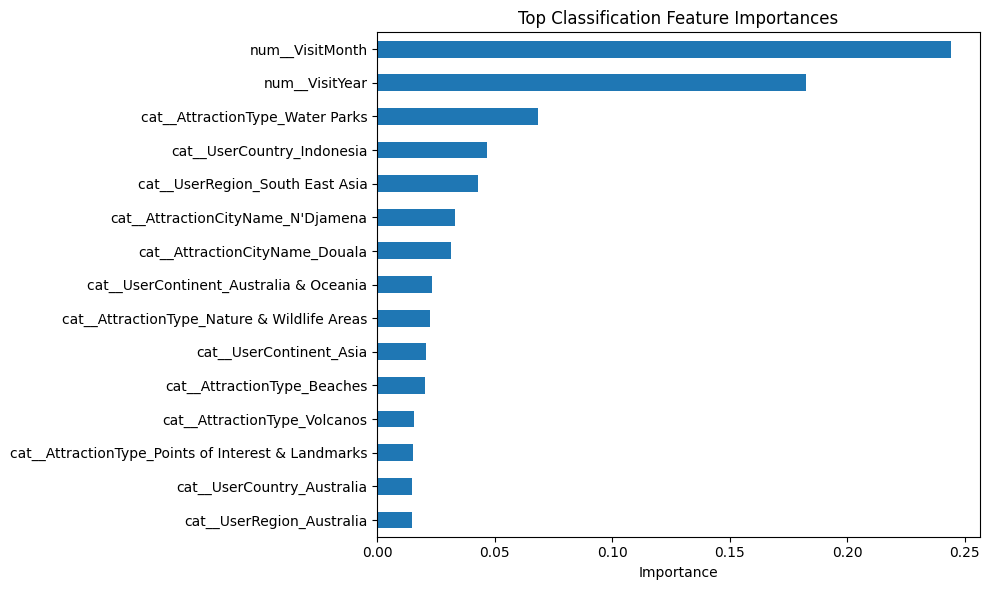

In [ ]:
# 15.1 Regression feature importance, when available
if best_reg_name == "Random Forest":
    fitted_pre = reg_model.named_steps["preprocessor"]
    rf = reg_model.named_steps["model"]
    feature_names = fitted_pre.get_feature_names_out()
    importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
    display(importance.to_frame("Importance"))
    plt.figure(figsize=(10, 6))
    importance.sort_values().plot(kind="barh")
    plt.title("Top Regression Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Ridge Regression selected; tree-based feature importance is not applicable.")

# 15.2 Classification feature importance, when available
if best_clf_name == "Random Forest":
    fitted_pre = clf_model.named_steps["preprocessor"]
    rf = clf_model.named_steps["model"]
    feature_names = fitted_pre.get_feature_names_out()
    importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
    display(importance.to_frame("Importance"))
    plt.figure(figsize=(10, 6))
    importance.sort_values().plot(kind="barh")
    plt.title("Top Classification Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Logistic Regression selected; tree-based feature importance is not applicable.")

## 16. Final Results and Limitations

### Final results
The tables below collect the selected model metrics and recommendation metrics in one place for the project report.

### Limitations to report honestly

- The classification task is based on the fields available in the supplied data; it does not include a user's future trip intent.
- Many users have only one recorded transaction, so personalized recommendation quality is evaluated on the subset of users with at least two historical interactions.
- The source attraction-type table contains a schema inconsistency between numeric IDs and a small set of descriptive labels. The notebook documents and standardizes those labels rather than dropping the affected rows.
- Model metrics are empirical results on the supplied dataset and should not be represented as guaranteed real-world performance.

In [ ]:
# 16.1 Consolidated final metrics
final_results = {
    "Regression model": best_reg_name,
    "Regression MAE": float(reg_comparison.iloc[0]["MAE"]),
    "Regression RMSE": float(reg_comparison.iloc[0]["RMSE"]),
    "Regression R2": float(reg_comparison.iloc[0]["R2"]),
    "Classification model": best_clf_name,
    "Classification Accuracy": float(clf_comparison.iloc[0]["Accuracy"]),
    "Classification Precision (weighted)": float(clf_comparison.iloc[0]["Precision_weighted"]),
    "Classification Recall (weighted)": float(clf_comparison.iloc[0]["Recall_weighted"]),
    "Classification F1 (weighted)": float(clf_comparison.iloc[0]["F1_weighted"]),
    "Recommendation RMSE": float(recommendation_rmse),
    "Recommendation Hit Rate@5": float(hit_rate_at_5),
}

display(pd.DataFrame([final_results]).T.rename(columns={0: "Value"}))

,Value
Regression model,Random Forest
Regression MAE,0.716
Regression RMSE,0.920
Regression R2,0.101
Classification model,Random Forest
Classification Accuracy,0.380
Classification Precision (weighted),0.443
Classification Recall (weighted),0.380
Classification F1 (weighted),0.401
Recommendation RMSE,1.146


## 17. Export Cleaned Data, Models, Recommendation Artifacts, and Metrics

These files support reproducible Streamlit deployment and portfolio sharing.

In [ ]:
# 17.1 Save outputs
clean_path = OUTPUT_DIR / "tourism_master_dataset_cleaned.csv"
master.to_csv(clean_path, index=False)

# Also keep the expected deployment filename at the project data root.
deploy_master_path = DATA_DIR / "tourism_master_dataset.csv"
master.to_csv(deploy_master_path, index=False)

reg_model_path = MODEL_DIR / "rating_regressor.joblib"
clf_model_path = MODEL_DIR / "visit_mode_classifier.joblib"
rec_artifact_path = MODEL_DIR / "recommendation_artifacts.joblib"
metrics_path = MODEL_DIR / "model_metrics.json"

joblib.dump(reg_model, reg_model_path)
joblib.dump(clf_model, clf_model_path)

recommendation_artifacts = {
    "user_index": user_index,
    "item_index": item_index,
    "item_ids": item_ids,
    "item_similarity": item_similarity,
    "train_matrix": train_matrix,
    "item_meta": item_meta,
    "global_mean": train_global_mean,
}
joblib.dump(recommendation_artifacts, rec_artifact_path)

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2)

print("Saved:")
for p in [clean_path, deploy_master_path, reg_model_path, clf_model_path, rec_artifact_path, metrics_path]:
    print(" -", p)

Saved:
 - ../outputs/tourism_master_dataset_cleaned.csv
 - /content/tourism_master_dataset.csv
 - ../models/rating_regressor.joblib
 - ../models/visit_mode_classifier.joblib
 - ../models/recommendation_artifacts.joblib
 - ../models/model_metrics.json


## 18. Reproducibility Checklist

Before submission, confirm that:

- [x] Source datasets are loaded from the project `data/` directory.
- [x] Duplicate rows are checked and removed.
- [x] Foreign-key relationships are validated before joins.
- [x] Missing values are explicitly handled.
- [x] Source inconsistencies are documented and standardized.
- [x] EDA covers ratings, visit modes, continents, countries, regions, attraction types, and time trends.
- [x] Regression includes model comparison and MAE/RMSE/R².
- [x] Classification includes model comparison and accuracy/precision/recall/F1.
- [x] Recommendation uses historical user interactions for personalization.
- [x] Recommendation evaluation includes RMSE and Hit Rate@5.
- [x] Final models and recommendation artifacts are exported for deployment.
- [x] Business insights and limitations are documented honestly.

**Final conclusion:** The notebook provides an end-to-end, reproducible implementation of the supplied Tourism Experience Analytics brief and is structured for portfolio, GitHub, and Streamlit use.